Side-by-side execution figure saved successfully!


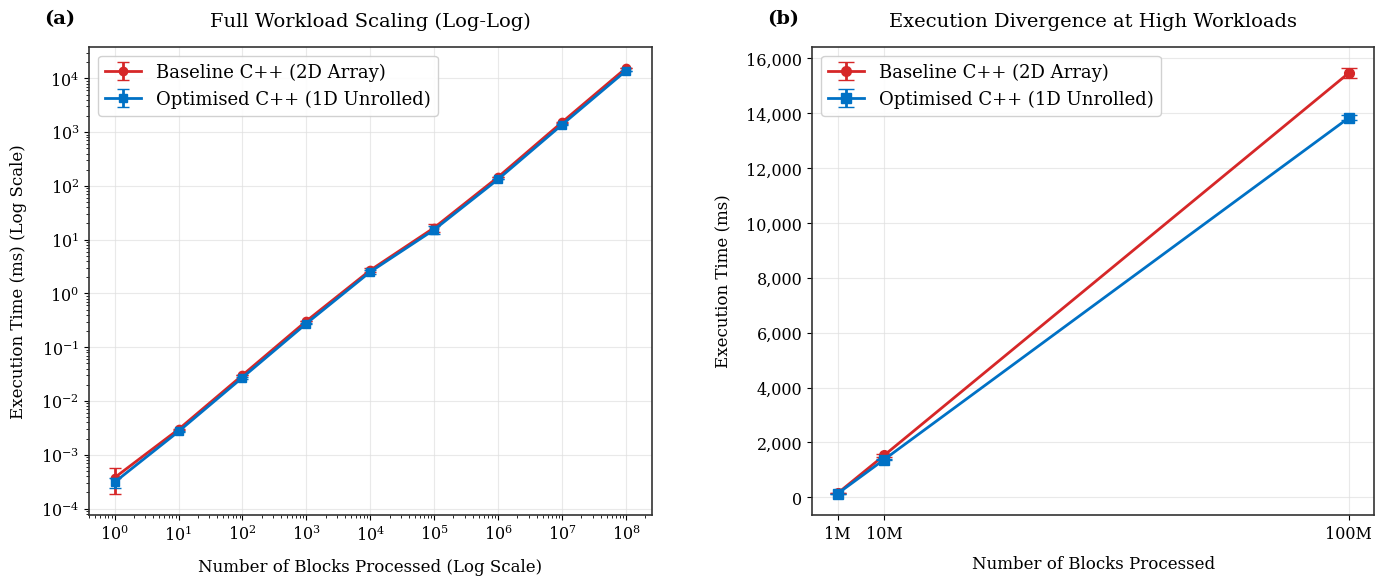

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.ticker as ticker

# Global academic plot styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11.5,          
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'axes.linewidth': 1.2,
    'axes.edgecolor': '#333333'
})

file_readable = 'readable_results.csv'
file_optimized = 'optimised_results.csv'

if not os.path.exists(file_readable) or not os.path.exists(file_optimized):
    raise FileNotFoundError("Missing CSV files! run BOTH C++ scripts first.")

df_readable = pd.read_csv(file_readable)
df_optimized = pd.read_csv(file_optimized)

# Calculate stats for all data
readable_stats = df_readable.groupby('Blocks')['Time_ms'].agg(['mean', 'std']).reset_index()
optimized_stats = df_optimized.groupby('Blocks')['Time_ms'].agg(['mean', 'std']).reset_index()

# Filter data for the zoomed-in divergence plot
readable_zoom = readable_stats[readable_stats['Blocks'] >= 1000000]
optimized_zoom = optimized_stats[optimized_stats['Blocks'] >= 1000000]

color_readable = '#d62728'  
color_optimized = '#0071C5' 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot (a): Full Log-Log Scaling
ax1.errorbar(readable_stats['Blocks'], readable_stats['mean'], yerr=readable_stats['std'], 
             fmt='-o', capsize=4, label='Baseline C++ (2D Array)', color=color_readable, linewidth=2, markersize=6, zorder=3)
ax1.errorbar(optimized_stats['Blocks'], optimized_stats['mean'], yerr=optimized_stats['std'], 
             fmt='-s', capsize=4, label='Optimised C++ (1D Unrolled)', color=color_optimized, linewidth=2, markersize=6, zorder=4)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Full Workload Scaling (Log-Log)', pad=15)
ax1.set_xlabel('Number of Blocks Processed (Log Scale)', labelpad=10)
ax1.set_ylabel('Execution Time (ms) (Log Scale)', labelpad=10)

ax1.grid(True, which="major", linestyle='-', color='#e0e0e0', alpha=0.7, zorder=0)
ax1.legend(loc='upper left',  framealpha=0.9, edgecolor='#cccccc', fontsize=13)
ax1.text(-0.08, 1.05, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold')

# Right Plot (b): Divergence at High Workloads (Linear)
ax2.errorbar(readable_zoom['Blocks'], readable_zoom['mean'], yerr=readable_zoom['std'], 
             fmt='-o', capsize=6, label='Baseline C++ (2D Array)', color=color_readable, linewidth=2, markersize=7, zorder=3)
ax2.errorbar(optimized_zoom['Blocks'], optimized_zoom['mean'], yerr=optimized_zoom['std'], 
             fmt='-s', capsize=6, label='Optimised C++ (1D Unrolled)', color=color_optimized, linewidth=2, markersize=7, zorder=4)

ax2.set_title(r'Execution Divergence at High Workloads', pad=15)
ax2.set_xlabel('Number of Blocks Processed', labelpad=10)
ax2.set_ylabel('Execution Time (ms)', labelpad=10)

x_labels = [f"{int(x/1000000)}M" for x in readable_zoom['Blocks']]
ax2.set_xticks(readable_zoom['Blocks'])
ax2.set_xticklabels(x_labels)

ax2.grid(True, linestyle='-', color='#e0e0e0', alpha=0.7, zorder=0)
ax2.legend(loc='upper left', framealpha=0.9, edgecolor='#cccccc', fontsize=13)
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2.text(-0.08, 1.05, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold')

plt.tight_layout(w_pad=4.0)
plt.savefig('cpp_execution_scaling.png', dpi=300, bbox_inches='tight')
print("Side-by-side execution figure saved successfully!")
plt.show()